###Bibliotheken einfügen


In [2]:
# import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import requests
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.stattools import adfuller

###Goldpreis von Alpha Vantage ziehen


In [3]:
# Dein API-Schlüssel von Alpha Vantage
api_key = 'JX03FK2W87N81TEN'

# API-Endpunkt für den täglichen Goldpreis (XAU/USD)
url = f'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=XAUUSD&apikey={api_key}&outputsize=full'

 # API-Anfrage senden
response = requests.get(url)
data = response.json()

# Die historischen Daten aus der Antwort extrahieren
if "Time Series (Daily)" in data:   
    time_series = data["Time Series (Daily)"]

    # Die Daten in ein pandas DataFrame umwandeln
    df = pd.DataFrame.from_dict(time_series, orient='index')
    df = df.astype(float)  # Umwandeln der Daten in numerische Werte
    df = df.rename(columns={'4. close': 'Goldpreis_am_Tag'})
    df = df['Goldpreis_am_Tag'] #Spalten löschen
    df.index = pd.to_datetime(df.index)  # Index als Datum umwandeln

    # Speichern der Daten als CSV-Datei
    df.to_csv(r'C:\Users\johan\Desktop\Neuer Ordner\Goldpreis.csv')
    print('Daten wurden erfolgreich als CSV gespeichert.')
    
# Ausgabe der ersten Zeilen des DataFrames
    print(df.head())
    print(len(df))
    print(df.index.min())  # Ältestes Datum
    print(df.index.max())  # Neuestes Datum

else:
    print("Fehlerhafte API-Antwort:")
    print(data)
    


Daten wurden erfolgreich als CSV gespeichert.
2025-05-23    3356.44
2025-05-22    3300.12
2025-05-21    3320.12
2025-05-20    3290.75
2025-05-19    3222.64
Name: Goldpreis_am_Tag, dtype: float64
1629
2019-01-28 00:00:00
2025-05-23 00:00:00


##Vorverarbeitung

In [4]:
# Vorverarbeitung und filtern
df_goldpreis=pd.read_csv('Goldpreis.csv', index_col=0, parse_dates=True) # einlesen
df_goldpreis.index = pd.to_datetime(df_goldpreis.index) #Datum umwandeln
df_goldpreis = df_goldpreis[df_goldpreis.index > pd.Timestamp('2021-01-01')] # nach 2021 filtern

# Da Datenpunkte an Wochenenden nicht plausibel sind, wurden sie gelöscht
# print(df_goldpreis.index.dayofweek.value_counts())
df_goldpreis = df_goldpreis[df_goldpreis.index.dayofweek < 5]
print(len(df_goldpreis))


1107


##Vollständigkeitsprüfung. Die Daten liegen erst ab 2021 vollständig vor.

In [5]:
# Die Daten werden auf Vollständigkeit abgeglichen mit allen möglichen Werktagen
# Dazu werden alle Werktage seit 2021 in eine Liste gespeichert
Werktage_seit_2021 = pd.date_range(start='1/1/2021', end='12/05/2025', freq='D')
Werktage_seit_2021 = Werktage_seit_2021[Werktage_seit_2021.dayofweek < 5]
Werktage_seit_2021 = Werktage_seit_2021.normalize()
print(len(Werktage_seit_2021))

# Überprüfung, für welche Werktage keine Daten vorliegen
counter=0
Fehlwerte=[]
for i in Werktage_seit_2021:
    if i not in df_goldpreis.index.normalize():
        counter += 1
        Fehlwerte.append(i)
        # if i < pd.Timestamp('2021-01-01'):
            # print(i) 
            ## --> 185 Fehlwerte in 2020
            # counter_2020 += 1

print(counter)

# Abgleich mit den Werktagen, an denen die Börse geschlossen war
import pandas_market_calendars as mcal

# NYSE-Kalender laden
nyse = mcal.get_calendar('NYSE')

# Handelszeitplan abrufen (enthält nur Handelstage)
schedule = nyse.schedule(start_date='2021-01-01', end_date='2024-12-31')

richtige_Fehlwerte=[]
falsche_Fehlwerte=[]
for i in Fehlwerte:
    if i not in schedule: 
        richtige_Fehlwerte.append(i)
    elif i in schedule:
        falsche_Fehlwerte.append(i)

print('Fehlwerte an Schließtagen: ' + str(len(richtige_Fehlwerte))) 
print('Wirkliche Fehlwerte: ' + str (len(falsche_Fehlwerte)))

# Fazit: Es liegen für alle Werktage, an denen die Börse geöffnet war, Daten vor.

1286
179
Fehlwerte an Schließtagen: 179
Wirkliche Fehlwerte: 0


###Maximalwertuntersuchung und Outlier Detection 

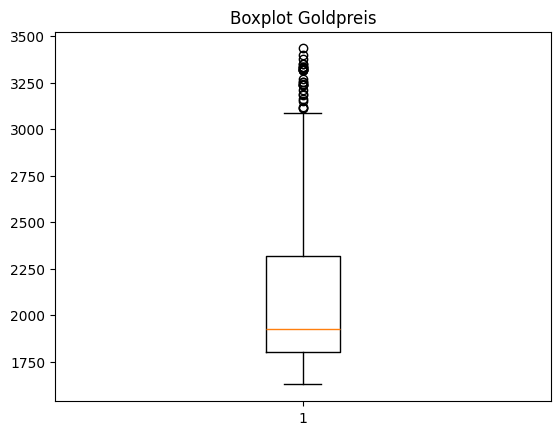

Anzahl an Outliern:1107
            Goldpreis_am_Tag
2025-05-15           3151.89
2025-05-14           3186.08
2025-05-13           3254.46
2025-05-12           3236.87
2025-05-09           3326.97
...                      ...
2021-02-12               NaN
2021-02-11               NaN
2021-02-10               NaN
2021-02-09               NaN
2021-02-08               NaN

[1107 rows x 1 columns]


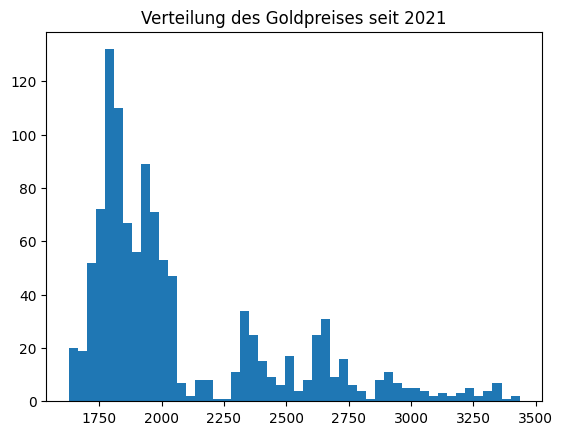

<Figure size 640x480 with 0 Axes>

In [6]:
#Boxplot für Überblick
plt.boxplot(df_goldpreis)
plt.title('Boxplot Goldpreis')
plt.show()
plt.clf()

#Ausreißer finden
def find_outliers_IQR(df):
   q1=df.quantile(0.25)
   q3=df.quantile(0.75)
   IQR=q3-q1
   outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]
   return outliers

print('Anzahl an Outliern:' + str(len(find_outliers_IQR(df_goldpreis))))
print(find_outliers_IQR(df_goldpreis))
# --> Online Abgleich: nur plausible Werte

plt.title('Verteilung des Goldpreises seit 2021')
plt.hist(df_goldpreis, bins=50)
plt.show()
plt.clf()

##Goldpreis im Zeitverlauf

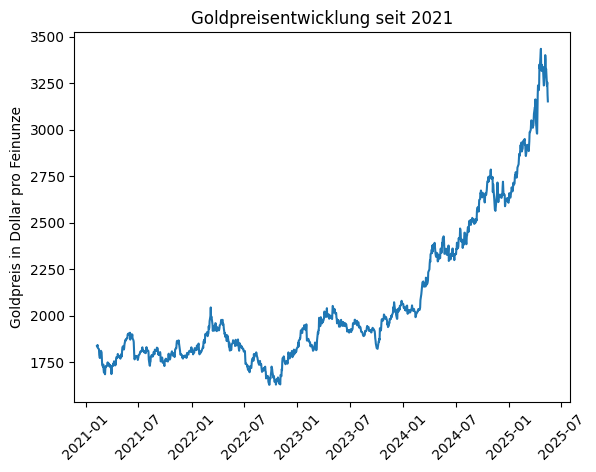

<Figure size 640x480 with 0 Axes>

In [7]:
# Goldpreisentwicklung
ax = plt.subplot(1, 1, 1)
plt.title('Goldpreisentwicklung seit 2021')
plt.plot(df_goldpreis)
plt.ylabel('Goldpreis in Dollar pro Feinunze')
plt.xticks(rotation=45)
plt.show()
plt.clf()

##ACF-PACF Plots

<Figure size 1200x600 with 0 Axes>

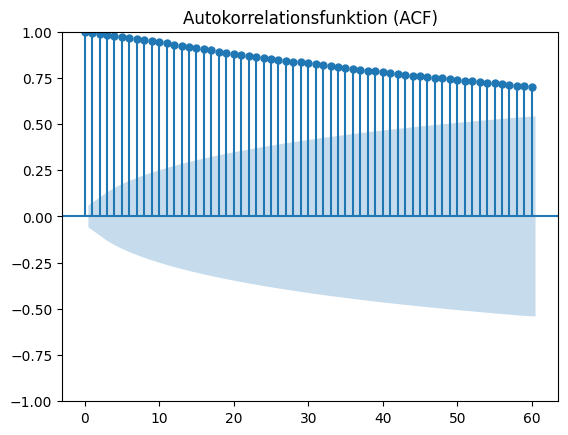

<Figure size 1200x600 with 0 Axes>

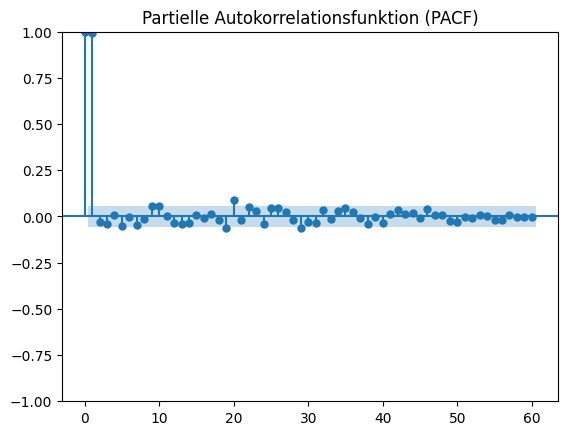

In [8]:
# Plotten der ACF und PACF
plt.figure(figsize=(12, 6))
plot_acf(df_goldpreis, lags=60, alpha=0.05)
plt.title('Autokorrelationsfunktion (ACF)')
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(df_goldpreis, lags=60, alpha=0.05)
plt.title('Partielle Autokorrelationsfunktion (PACF)')
plt.show()#

##Stationarität prüfen

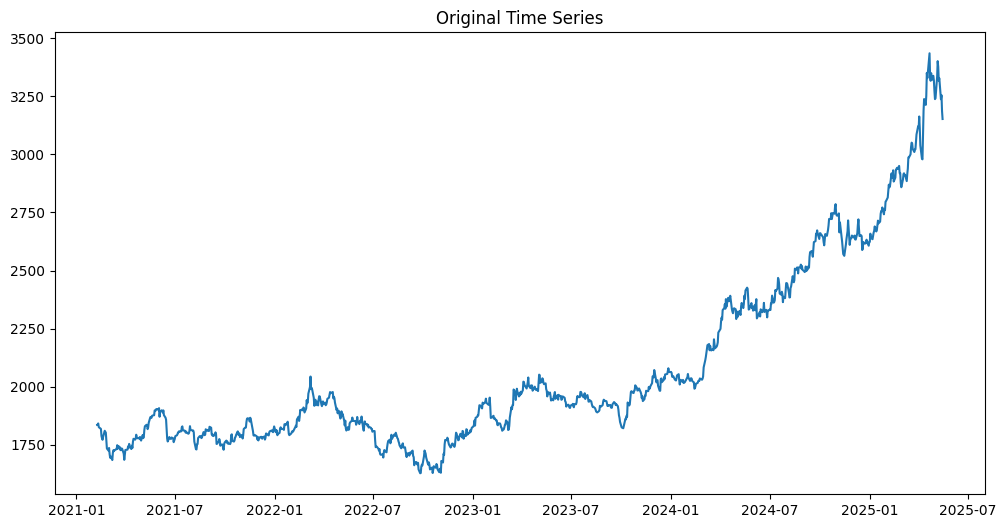

ADF-Test für die ursprüngliche Zeitreihe:
ADF Statistic: -3.4452967170058515
p-value: 0.00950828630907152
Critical Values:
	1%: -3.436287110400734
	5%: -2.864161528982321
	10%: -2.5681657829565743


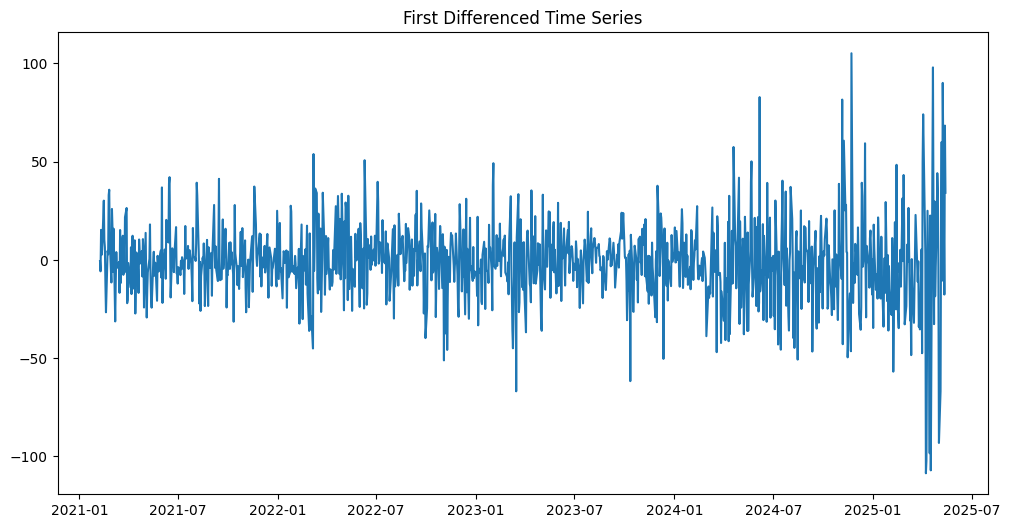


ADF-Test für die erste Differenzierung:
ADF Statistic: -23.9893781599648
p-value: 0.0
Critical Values:
	1%: -3.436287110400734
	5%: -2.864161528982321
	10%: -2.5681657829565743


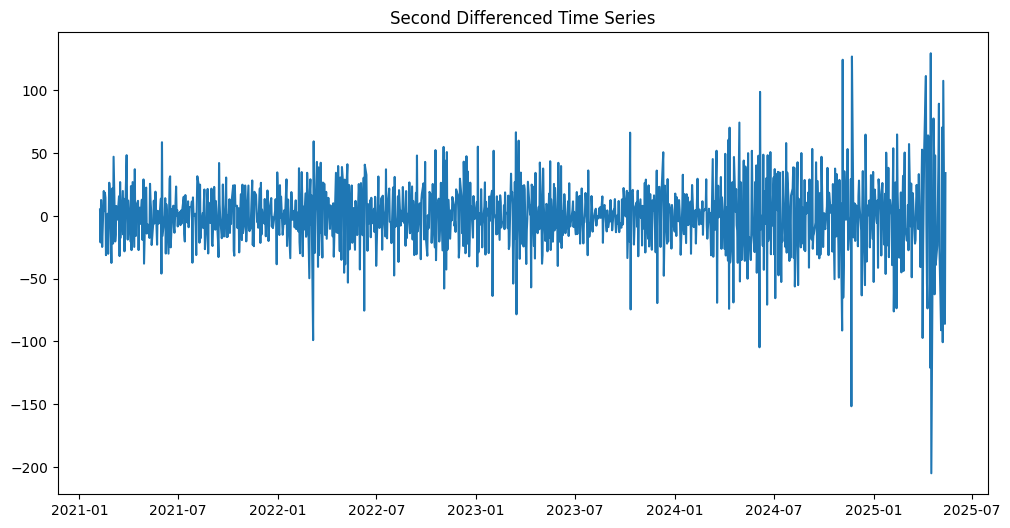


ADF-Test für die zweite Differenzierung:
ADF Statistic: -12.212684825057519
p-value: 1.1541571786837552e-22
Critical Values:
	1%: -3.436402509014354
	5%: -2.8642124318084456
	10%: -2.568192893555997


<Figure size 1200x600 with 0 Axes>

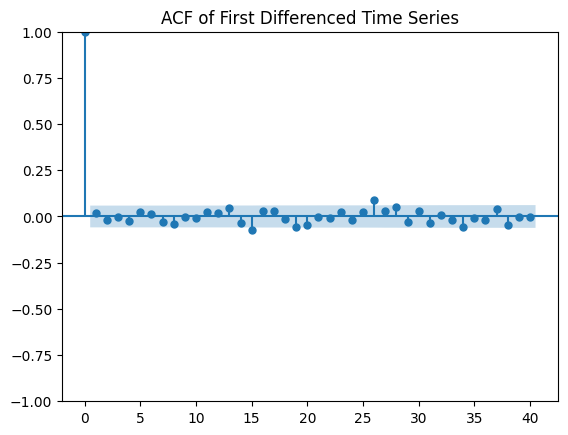

<Figure size 1200x600 with 0 Axes>

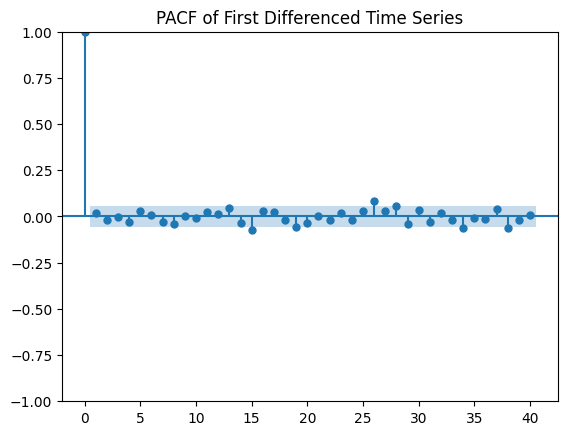

In [9]:
# Funktion zum ADF-Test
def adf_test(timeseries):
    result = adfuller(timeseries)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')

# Plot der ursprünglichen Zeitreihe
plt.figure(figsize=(12, 6))
plt.plot(df_goldpreis)
plt.title('Original Time Series')
plt.show()

# ADF-Test für die ursprüngliche Zeitreihe
print("ADF-Test für die ursprüngliche Zeitreihe:")
adf_test(df_goldpreis)

# Erste Differenzierung
first_diff = df_goldpreis.diff().dropna()

# Plot der ersten Differenzierung
plt.figure(figsize=(12, 6))
plt.plot(first_diff)
plt.title('First Differenced Time Series')
plt.show()

# ADF-Test für die erste Differenzierung
print("\nADF-Test für die erste Differenzierung:")
adf_test(first_diff)

# Zweite Differenzierung (falls erforderlich)
second_diff = first_diff.diff().dropna()

# Plot der zweiten Differenzierung
plt.figure(figsize=(12, 6))
plt.plot(second_diff)
plt.title('Second Differenced Time Series')
plt.show()

# ADF-Test für die zweite Differenzierung
print("\nADF-Test für die zweite Differenzierung:")
adf_test(second_diff)

# Plot der ACF und PACF für die differenzierten Zeitreihen
plt.figure(figsize=(12, 6))
plot_acf(first_diff, lags=40, alpha=0.05)
plt.title('ACF of First Differenced Time Series')
plt.show()

plt.figure(figsize=(12, 6))
plot_pacf(first_diff, lags=40, alpha=0.05)
plt.title('PACF of First Differenced Time Series')
plt.show()


##Goldpreis nach Wochentagen

   Wochentag  Goldpreis_am_Tag
0        0.0       2072.229372
1        1.0       2073.948655
2        2.0       2076.090897
3        3.0       2079.692500
4        4.0       2071.298588
5        7.0       2074.652002


ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (8).

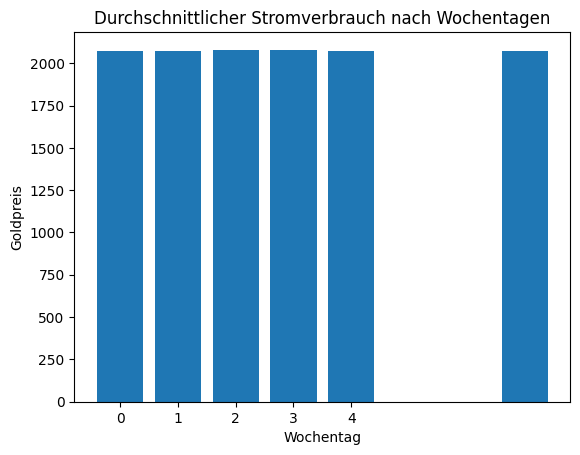

In [17]:
# Wochentag: Montag = 0 .. Sonntag = 6
df_goldpreis['Wochentag'] = df_goldpreis.index.weekday
#Mittelwert für gesamtverbrauch pro Wochentag
mean_per_weekday = df_goldpreis.groupby('Wochentag')['Goldpreis_am_Tag'].mean().reset_index()
mean_weekdays = mean_per_weekday['Goldpreis_am_Tag'].mean()
mean_per_weekday.loc[len(mean_per_weekday.index)] = [7, mean_weekdays]
print(mean_per_weekday)

# Balkendiagramm erstellen
ax = plt.subplot(1,1,1)
plt.bar(mean_per_weekday['Wochentag'], mean_per_weekday['Goldpreis_am_Tag'])
plt.title('Durchschnittlicher Stromverbrauch nach Wochentagen')
plt.xlabel('Wochentag')
plt.ylabel('Goldpreis')
ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7])
ax.set_xticklabels(['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So', 'Alle'])
plt.show()
plt.clf()

##Goldpreis nach Monat

    Monat  Goldpreis_am_Tag
0       1       2123.637809
1       2       2102.058958
2       3       2132.356955
3       4       2260.336553
4       5       2155.322800
5       6       1976.829419
6       7       1979.784483
7       8       1981.917389
8       9       1980.477093
9      10       2032.241395
10     11       2039.256782
11     12       2066.899885


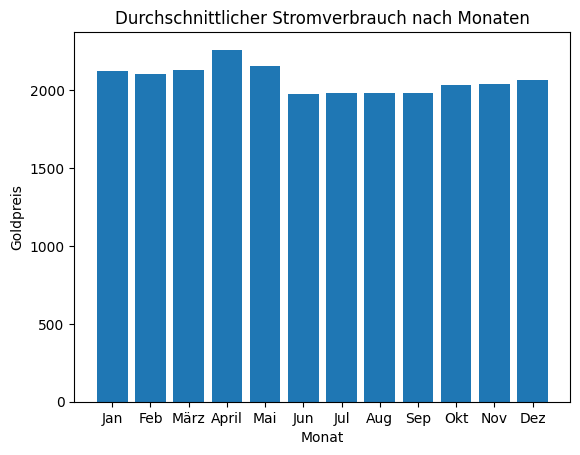

<Figure size 640x480 with 0 Axes>

In [16]:
# Wochentag: Montag = 0 .. Sonntag = 6
df_goldpreis['Monat'] = df_goldpreis.index.month
#Mittelwert für gesamtverbrauch pro Wochentag
mean_per_month = df_goldpreis.groupby('Monat')['Goldpreis_am_Tag'].mean().reset_index()
mean_months = mean_per_month['Goldpreis_am_Tag'].mean()
# mean_per_weekday.loc[len(mean_per_weekday.index)] = [7, mean_weekdays]
print(mean_per_month)

# Balkendiagramm erstellen
ax = plt.subplot(1,1,1)
plt.bar(mean_per_month['Monat'], mean_per_month['Goldpreis_am_Tag'])
plt.title('Durchschnittlicher Stromverbrauch nach Monaten')
plt.xlabel('Monat')
plt.ylabel('Goldpreis')
ax.set_xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
ax.set_xticklabels(['Jan', 'Feb', 'März', 'April', 'Mai', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dez'])
plt.show()
plt.clf()

##Goldpreis nach Wochentag und Monat

   Wochentag  Goldpreis_am_Tag
0        7.0               NaN


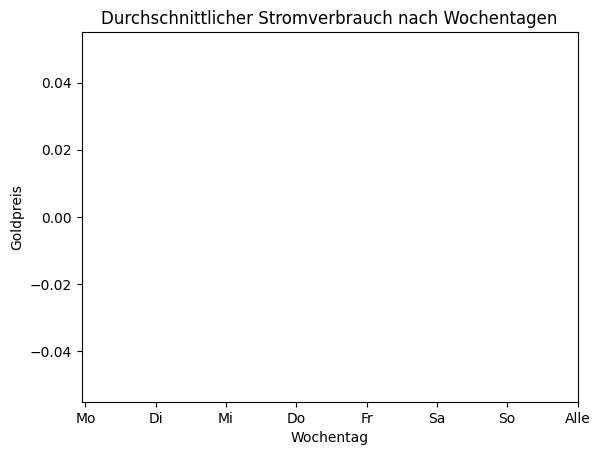

   Wochentag  Goldpreis_am_Tag
0        0.0       2078.589211
1        1.0       2100.190556
2        2.0       2139.848056
3        3.0       2150.641471
4        4.0       2154.645294
5        7.0       2124.782917


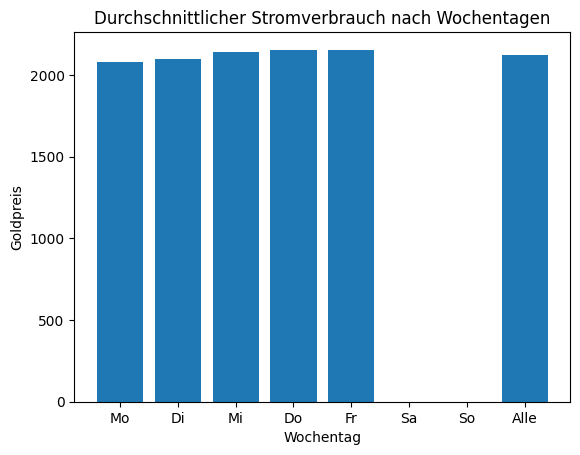

   Wochentag  Goldpreis_am_Tag
0        0.0       2106.483158
1        1.0       2098.537368
2        2.0       2108.210789
3        3.0       2100.633250
4        4.0       2096.505263
5        7.0       2102.073966


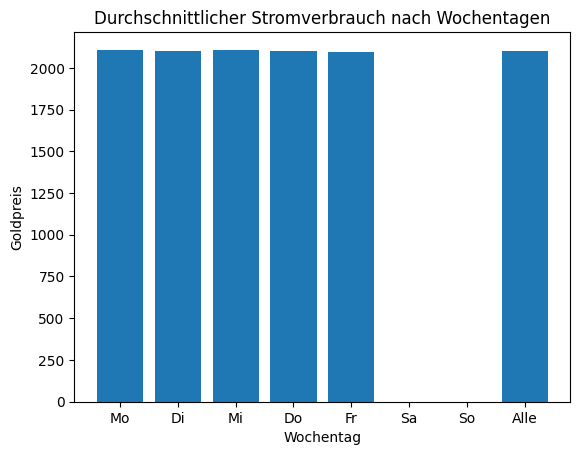

   Wochentag  Goldpreis_am_Tag
0        0.0       2165.287273
1        1.0       2112.497500
2        2.0       2109.005652
3        3.0       2133.983636
4        4.0       2142.534762
5        7.0       2132.661765


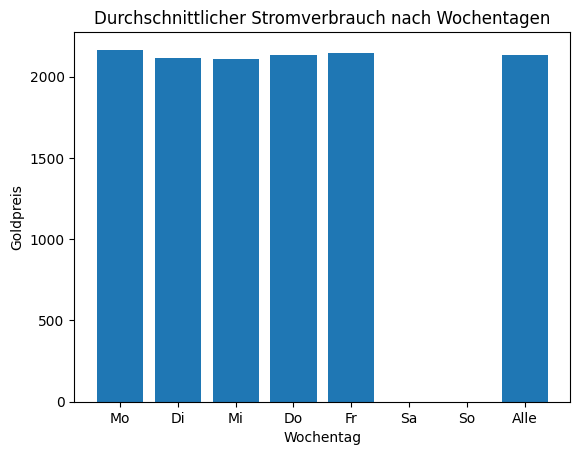

   Wochentag  Goldpreis_am_Tag
0        0.0       2254.534048
1        1.0       2293.186136
2        2.0       2301.218571
3        3.0       2235.676190
4        4.0       2208.031389
5        7.0       2258.529267


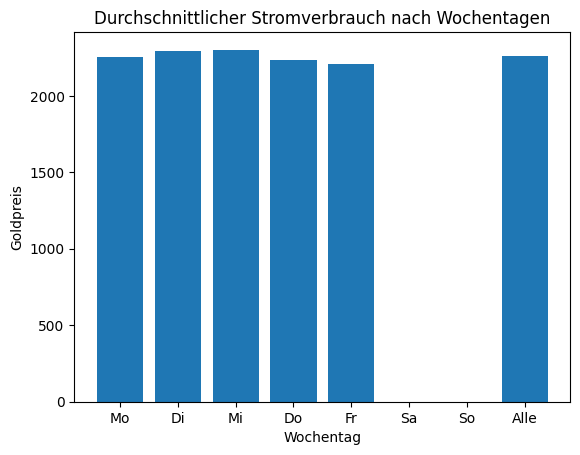

   Wochentag  Goldpreis_am_Tag
0        0.0       2117.752143
1        1.0       2134.393500
2        2.0       2154.228250
3        3.0       2208.967500
4        4.0       2163.563158
5        7.0       2155.780910


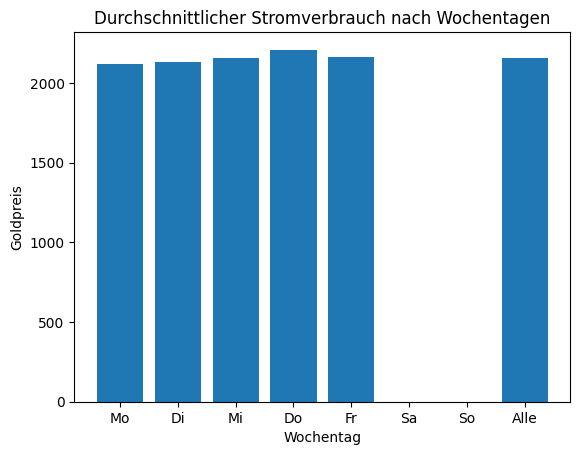

   Wochentag  Goldpreis_am_Tag
0        0.0       1984.975312
1        1.0       1973.955294
2        2.0       1965.957778
3        3.0       1978.516944
4        4.0       1981.761176
5        7.0       1977.033301


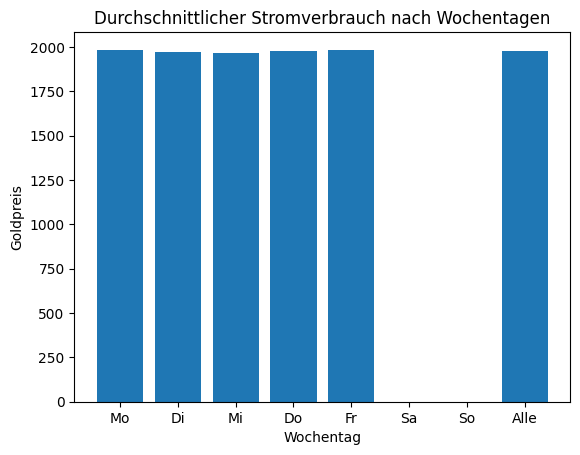

   Wochentag  Goldpreis_am_Tag
0        0.0       1988.454444
1        1.0       1995.460588
2        2.0       2000.629118
3        3.0       1961.351471
4        4.0       1954.031667
5        7.0       1979.985458


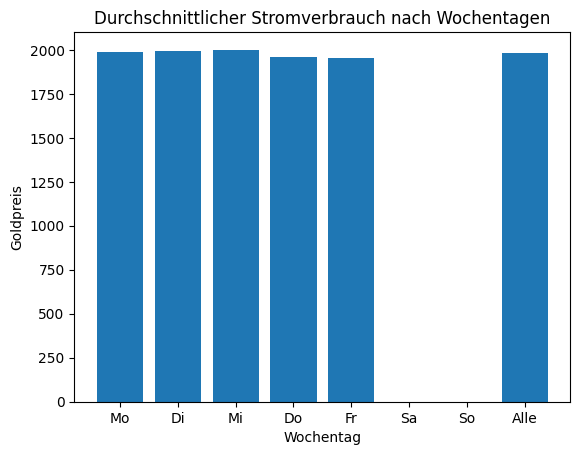

   Wochentag  Goldpreis_am_Tag
0        0.0       1962.352222
1        1.0       1960.070789
2        2.0       1965.994722
3        3.0       2008.768889
4        4.0       2015.478529
5        7.0       1982.533030


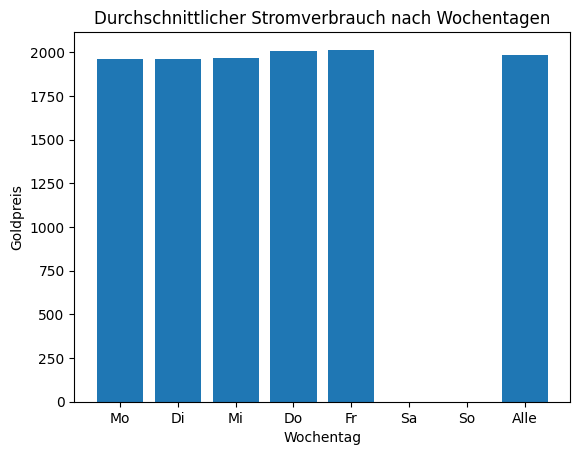

   Wochentag  Goldpreis_am_Tag
0        0.0       2025.649118
1        1.0       1983.020937
2        2.0       1969.994706
3        3.0       1956.699722
4        4.0       1969.230833
5        7.0       1980.919063


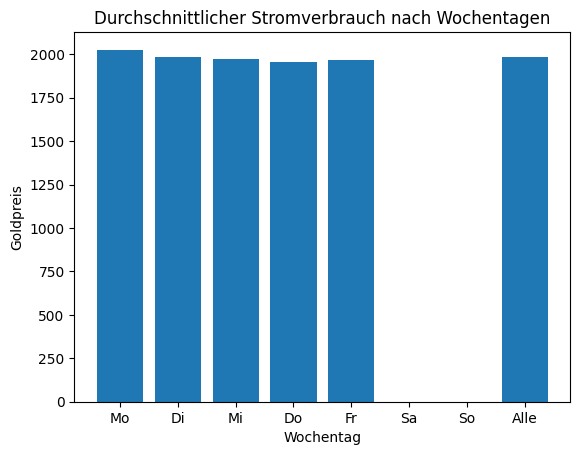

   Wochentag  Goldpreis_am_Tag
0        0.0       1985.286389
1        1.0       2044.817778
2        2.0       2053.262059
3        3.0       2080.606563
4        4.0       2002.101471
5        7.0       2033.214852


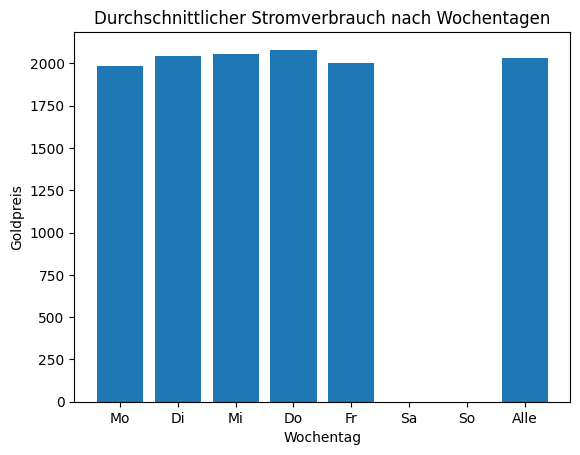

   Wochentag  Goldpreis_am_Tag
0        0.0       2029.551176
1        1.0       2013.548333
2        2.0       2021.013056
3        3.0       2043.976765
4        4.0       2090.780000
5        7.0       2039.773866


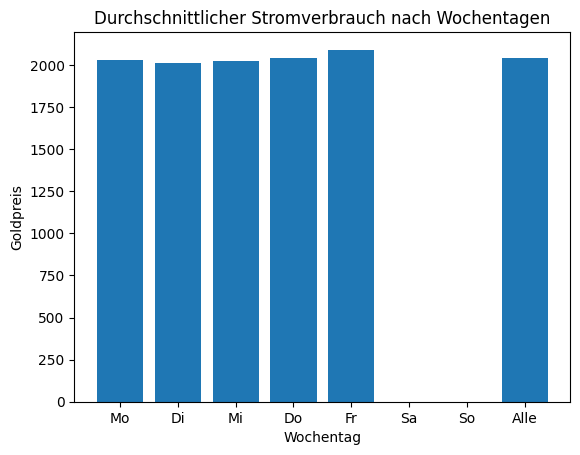

<Figure size 640x480 with 0 Axes>

In [14]:
def Balkendiagramm_Wochentag(data, Monat):
    data = data[data['Monat'] == Monat]
    mean_per_weekday = data.groupby('Wochentag')['Goldpreis_am_Tag'].mean().reset_index()
    mean_weekdays = mean_per_weekday['Goldpreis_am_Tag'].mean()
    mean_per_weekday.loc[len(mean_per_weekday.index)] = [7, mean_weekdays]
    print(mean_per_weekday)

    # Balkendiagramm erstellen
    ax = plt.subplot(1,1,1)
    plt.bar(mean_per_weekday['Wochentag'], mean_per_weekday['Goldpreis_am_Tag'])
    plt.title('Durchschnittlicher Stromverbrauch nach Wochentagen')
    plt.xlabel('Wochentag')
    plt.ylabel('Goldpreis')
    ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7]) 
    ax.set_xticklabels(['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So', 'Alle'])
    plt.show()
    plt.clf()

Monate = range(12)

for Monat in Monate:
    Balkendiagramm_Wochentag(df_goldpreis, Monat)